In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/Superstore.csv", encoding="latin1")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df[["Discount", "Profit"]].head(10)

,Discount,Profit
0,0.00,41.9136
1,0.00,219.5820
2,0.00,6.8714
3,0.45,-383.0310
4,0.20,2.5164
5,0.00,14.1694
6,0.00,1.9656
7,0.20,90.7152
8,0.20,5.7825
9,0.00,34.4700


In [6]:
df["Discount"].describe()

count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64

In [7]:
low_discount = df[df["Discount"] < 0.30]["Profit"]

high_discount = df[df["Discount"] >= 0.30]["Profit"]

In [8]:
print("Low discount group:", len(low_discount))
print("High discount group:", len(high_discount))

Low discount group: 8601
High discount group: 1393


In [9]:
print("Average profit - Low discount:",
      low_discount.mean())

print("Average profit - High discount:",
      high_discount.mean())

Average profit - Low discount: 49.03767907220091
Average profit - High discount: -97.1830983488873


In [10]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [11]:
from scipy.stats import ttest_ind

In [12]:
t_stat, p_value = ttest_ind(
    low_discount,
    high_discount,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 16.1409994038947
P-value: 2.295180259233842e-54


In [13]:
from scipy.stats import t

# Difference between the two sample means
mean_difference = low_discount.mean() - high_discount.mean()

# Sample sizes
n1 = len(low_discount)
n2 = len(high_discount)

# Sample standard deviations
s1 = low_discount.std()
s2 = high_discount.std()

# Standard error of the difference
standard_error = np.sqrt(
    (s1**2 / n1) + (s2**2 / n2)
)

# Welch-Satterthwaite degrees of freedom
degrees_of_freedom = (
    ((s1**2 / n1) + (s2**2 / n2))**2
    /
    (
        ((s1**2 / n1)**2 / (n1 - 1))
        +
        ((s2**2 / n2)**2 / (n2 - 1))
    )
)

# 95% confidence interval
confidence_level = 0.95
alpha = 1 - confidence_level

t_critical = t.ppf(
    1 - alpha / 2,
    degrees_of_freedom
)

margin_of_error = t_critical * standard_error

ci_lower = mean_difference - margin_of_error
ci_upper = mean_difference + margin_of_error

print("Mean difference:", mean_difference)
print("95% Confidence Interval:")
print("Lower bound:", ci_lower)
print("Upper bound:", ci_upper)

Mean difference: 146.2207774210882
95% Confidence Interval:
Lower bound: 128.4519116603299
Upper bound: 163.9896431818465


In [14]:
technology_profit = df[df["Category"] == "Technology"]["Profit"]

furniture_profit = df[df["Category"] == "Furniture"]["Profit"]

office_profit = df[df["Category"] == "Office Supplies"]["Profit"]

In [15]:
print("Technology:")
print("Orders:", len(technology_profit))
print("Average profit:", technology_profit.mean())

print("\nFurniture:")
print("Orders:", len(furniture_profit))
print("Average profit:", furniture_profit.mean())

print("\nOffice Supplies:")
print("Orders:", len(office_profit))
print("Average profit:", office_profit.mean())

Technology:
Orders: 1847
Average profit: 78.75200221981592

Furniture:
Orders: 2121
Average profit: 8.699327109853845

Office Supplies:
Orders: 6026
Average profit: 20.3270495851311


In [16]:
from scipy.stats import f_oneway

f_stat, p_value_anova = f_oneway(
    technology_profit,
    furniture_profit,
    office_profit
)

print("F-statistic:", f_stat)
print("P-value:", p_value_anova)

F-statistic: 54.31102304381537
P-value: 3.469918346218076e-24


In [17]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.6 MB 12.9 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.6 MB 14.3 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 13.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- -----------------

In [18]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

profit_values = pd.concat([
    technology_profit,
    furniture_profit,
    office_profit
])

category_labels = (
    ["Technology"] * len(technology_profit)
    + ["Furniture"] * len(furniture_profit)
    + ["Office Supplies"] * len(office_profit)
)

tukey_result = pairwise_tukeyhsd(
    endog=profit_values,
    groups=category_labels,
    alpha=0.05
)

print(tukey_result)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
      Furniture Office Supplies  11.6277 0.1181 -2.1626 25.4181  False
      Furniture      Technology  70.0527    0.0  52.669 87.4364   True
Office Supplies      Technology   58.425    0.0 43.8977 72.9522   True
----------------------------------------------------------------------


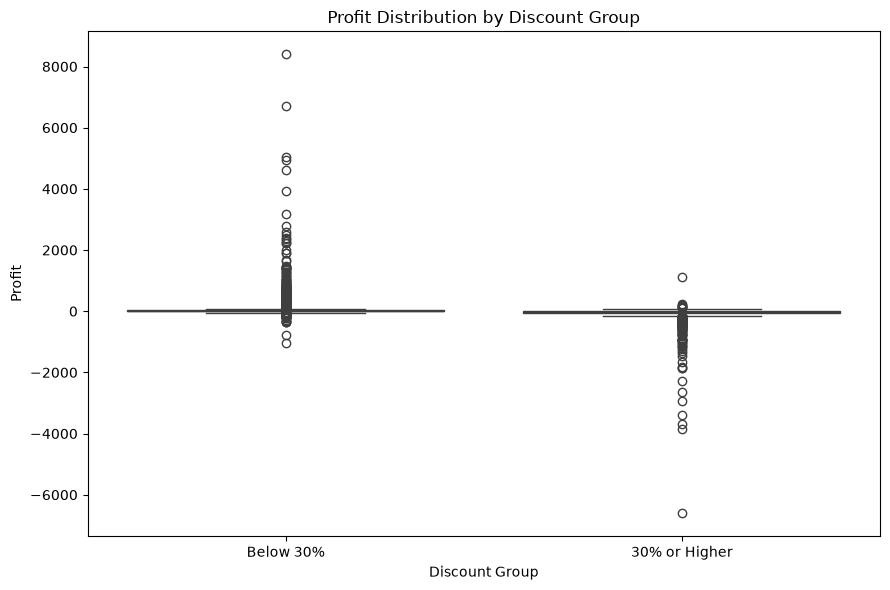

In [19]:
df["Discount Group"] = df["Discount"].apply(
    lambda x: "Below 30%" if x < 0.30 else "30% or Higher"
)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Discount Group",
    y="Profit"
)

plt.title("Profit Distribution by Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    "visualizations/profit_by_discount_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

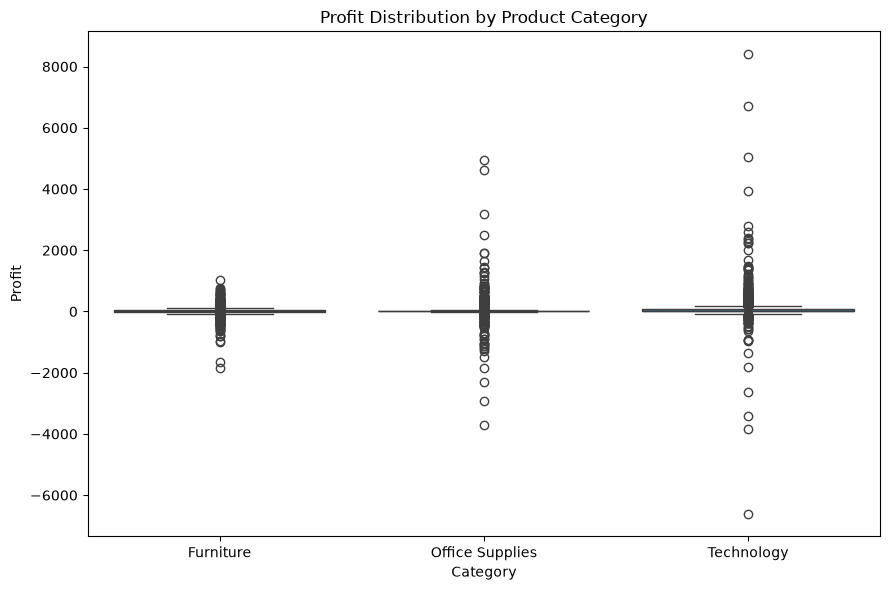

In [20]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit Distribution by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    "visualizations/profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
import numpy as np

mean1 = low_discount.mean()
mean2 = high_discount.mean()

sd1 = low_discount.std()
sd2 = high_discount.std()

n1 = len(low_discount)
n2 = len(high_discount)

pooled_sd = np.sqrt(
    ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2)
    / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: 0.6392684569235618
